# Notebook 02 — Preprocessing Data
## Dataset: Telco Customer Churn

Notebook ini menerjemahkan seluruh keputusan yang diambil berdasarkan EDA menjadi transformasi data yang nyata. Setiap langkah di sini memiliki alasan yang jelas dan bisa ditelusuri kembali ke temuan di Notebook 01.

Output utama notebook ini adalah file `processed_data.pkl` yang akan digunakan langsung oleh Notebook 03.

Ada tiga prinsip yang kita pegang sepanjang proses ini. Pertama, tidak ada informasi dari data test yang boleh bocor ke proses training. Kedua, setiap transformasi harus bisa direproduksi dan dijelaskan. Ketiga, preprocessing ini dirancang agar bisa diterapkan pada data baru di lingkungan produksi.

---

## 1. Memuat Library dan Data

Notebook ini mengambil alih dari titik mana EDA berakhir. Kita load dataset yang sama, kemudian menerapkan transformasi yang keputusannya sudah kita buat berdasarkan analisis di Notebook 01.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pickle, os, warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

possible_paths = [
    "../WA_Fn-UseC_-Telco-Customer-Churn.csv",
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv",
]

for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f" Data dimuat dari {path}")
        break

print(f"Shape awal: {df.shape}")
df.head(3)


 Data dimuat dari ../WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape awal: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Membersihkan Data

Ada dua masalah yang perlu diselesaikan berdasarkan temuan EDA.

**Kolom customerID** tidak mengandung informasi yang berguna untuk prediksi. Menyertakannya hanya menambah noise tanpa manfaat apapun.

**Kolom TotalCharges** mengandung 11 baris dengan spasi kosong yang menyebabkan kolom terbaca sebagai object. Setelah dikonversi ke numerik, baris-baris itu menjadi NaN. Dari EDA kita sudah tahu bahwa semua baris tersebut adalah pelanggan dengan tenure nol yang belum pernah ditagih. Jumlahnya sangat kecil (0,16% dari total), dan mereka tidak merepresentasikan kondisi yang relevan untuk model churn, sehingga keputusan paling tepat adalah mendrop baris tersebut.

In [2]:
# Step 1: Drop customerID
df.drop(columns=["customerID"], inplace=True)
print(" customerID di-drop")

# Step 2: Fix TotalCharges → numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_null = df["TotalCharges"].isnull().sum()
print(f"\n  TotalCharges NaN: {n_null} baris")
print("\nBaris bermasalah:")
display(df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

# Drop baris bermasalah (tenure=0, baru bergabung)
df.dropna(subset=["TotalCharges"], inplace=True)
print(f"\n Drop {n_null} baris. Shape baru: {df.shape}")


 customerID di-drop

  TotalCharges NaN: 11 baris

Baris bermasalah:


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No



 Drop 11 baris. Shape baru: (7032, 20)


## 3. Mengubah Fitur Kategorikal Menjadi Numerik

Model machine learning tidak bisa menerima input berupa teks. Semua fitur kategorikal harus dikonversi ke representasi angka.

Untuk kolom yang hanya memiliki dua nilai bermakna seperti Yes dan No, kita gunakan binary encoding sederhana karena lebih efisien dan tidak menambah kolom baru.

Untuk kolom dengan lebih dari dua kategori, kita gunakan one-hot encoding melalui `pd.get_dummies()`. Kita sengaja tidak menggunakan `drop_first` agar tidak ada informasi yang hilang secara implisit di dalam proses encoding.

In [3]:
# Binary encoding: Yes → 1, No → 0
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# Target encoding
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# One-hot encoding untuk fitur multi-kategori
multi_cols = [
    "gender", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df = pd.get_dummies(df, columns=multi_cols)

print(f" Encoding selesai. Shape: {df.shape}")
print(f"Total kolom: {df.shape[1]}")
df.head(2)


 Encoding selesai. Shape: (7032, 42)
Total kolom: 42


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Female,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,True,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,False,...,True,False,False,False,True,False,False,False,False,True


## 4. Membuat Fitur Baru

Feature engineering adalah proses menciptakan variabel baru yang lebih informatif dari variabel yang sudah ada, berdasarkan pemahaman bisnis dan insight dari EDA.

**avg_monthly_revenue** merepresentasikan rata-rata pendapatan bulanan yang sudah mempertimbangkan histori pembayaran total selama pelanggan berlangganan. Fitur ini lebih stabil dibanding Monthly Charges saja.

**service_count** menghitung jumlah total layanan tambahan yang dimiliki pelanggan. EDA menunjukkan bahwa pelanggan dengan lebih banyak layanan cenderung lebih terikat dan lebih loyal.

**tenure_group** mengkategorikan lama berlangganan ke dalam kelompok berdasarkan pola yang terlihat di EDA: pelanggan sangat baru, menengah, dan jangka panjang memiliki perilaku yang sangat berbeda meski perbedaan tenure absolutnya sama.

In [4]:
# Fitur baru 1: Rata-rata pendapatan per bulan
df["avg_monthly_revenue"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

# Fitur baru 2: Service count (jumlah layanan yang dimiliki)
service_cols_keywords = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                         "TechSupport", "StreamingTV", "StreamingMovies"]
# Hitung kolom hasil OHE yang menunjukkan 'Yes'
yes_cols = [c for c in df.columns if any(k in c for k in service_cols_keywords) and "_Yes" in c]
df["service_count"] = df[yes_cols].sum(axis=1)

# Fitur baru 3: Tenure group
bins   = [-1, 12, 24, 48, 72]
labels = [0, 1, 2, 3]   # 0=baru, 3=lama
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels).astype(int)

print(" Feature engineering selesai")
print("Fitur baru:", ["avg_monthly_revenue", "service_count", "tenure_group"])
print(f"Shape: {df.shape}")
df[["tenure", "avg_monthly_revenue", "service_count", "tenure_group"]].describe().round(2)


 Feature engineering selesai
Fitur baru: ['avg_monthly_revenue', 'service_count', 'tenure_group']
Shape: (7032, 45)


,tenure,avg_monthly_revenue,service_count,tenure_group
count,7032.00,7032.00,7032.00,7032.00
mean,32.42,64.80,2.04,1.55
std,24.55,30.19,1.85,1.23
min,1.00,13.78,0.00,0.00
25%,9.00,36.18,0.00,0.00
50%,29.00,70.37,2.00,2.00
75%,55.00,90.18,3.00,3.00
max,72.00,121.40,6.00,3.00


## 5. Pembagian Data dan Penanganan Ketidakseimbangan Kelas

Dengan rasio 73,5 persen berbanding 26,5 persen, model yang tidak menangani ketidakseimbangan ini cenderung bias ke kelas mayoritas. Sebuah model yang selalu memprediksi "tidak churn" sudah mencapai akurasi 73,5 persen — angka yang terlihat bagus tapi sama sekali tidak berguna.

Kita memilih SMOTE (Synthetic Minority Oversampling Technique) karena ia menciptakan sampel sintetis baru untuk kelas minoritas dengan cara menginterpolasi antara titik-titik yang sudah ada, bukan sekadar menduplikasi data yang sama berulang kali. Hasilnya lebih natural dan lebih kecil risiko overfitting ke sampel tertentu.

Yang sangat penting: SMOTE hanya diterapkan pada training set. Data test sengaja dibiarkan dengan distribusi aslinya karena itulah kondisi nyata yang akan dihadapi model ketika digunakan.

Distribusi target SEBELUM SMOTE:


Churn
0    5163
1    1869
Name: count, dtype: int64
Imbalance ratio: 2.76:1

Train: 5625 | Test: 1407



 Setelah SMOTE — Train: 8260 baris
Churn
0    4130
1    4130
Name: count, dtype: int64


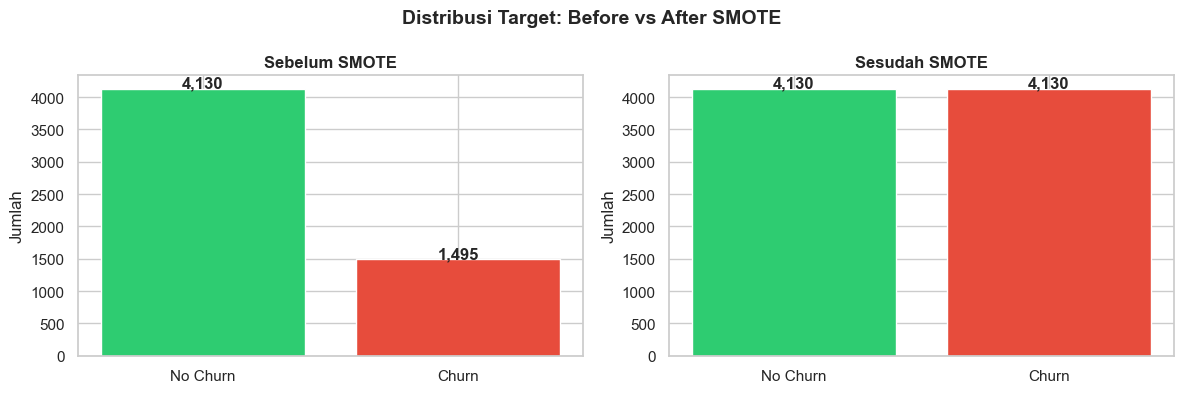

In [5]:
# Konversi bool → int
bool_cols = df.select_dtypes("bool").columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Distribusi target SEBELUM SMOTE:")
print(y.value_counts())
print(f"Imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1")

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# SMOTE hanya pada training set
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\n Setelah SMOTE — Train: {X_train_sm.shape[0]} baris")
print(pd.Series(y_train_sm).value_counts())

# Visualisasi before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#2ecc71", "#e74c3c"]

for ax, y_data, title in [(axes[0], y_train, "Sebelum SMOTE"), (axes[1], y_train_sm, "Sesudah SMOTE")]:
    counts = pd.Series(y_data).value_counts().sort_index()
    ax.bar(["No Churn", "Churn"], counts.values, color=colors)
    for i, (val) in enumerate(counts.values):
        ax.text(i, val + 20, f"{val:,}", ha="center", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Jumlah")

plt.suptitle("Distribusi Target: Before vs After SMOTE", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/smote_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Normalisasi Skala Fitur

Beberapa algoritma, terutama Logistic Regression, sensitif terhadap perbedaan skala. Fitur seperti TotalCharges yang bisa bernilai ribuan dolar akan mendominasi model dibanding fitur biner seperti SeniorCitizen yang hanya bernilai 0 atau 1.

StandardScaler dipilih karena mentransformasi data ke distribusi dengan rata-rata nol dan standar deviasi satu. Ini lebih tahan terhadap outlier dibanding MinMaxScaler yang bisa terdistorsi sangat jauh oleh satu nilai ekstrem saja.

Satu hal yang tidak boleh terlewat: scaler di-fit hanya pada training set, kemudian hasilnya diaplikasikan ke keduanya. Mem-fit scaler pada seluruh dataset termasuk test set adalah bentuk data leakage yang membuat evaluasi tampak lebih baik dari kenyataannya.

In [6]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_revenue"]

scaler = StandardScaler()
X_train_sm[num_features] = scaler.fit_transform(X_train_sm[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print(" StandardScaler diterapkan pada fitur numerik")
print("\nStatistik setelah scaling:")
pd.DataFrame(X_train_sm[num_features]).describe().round(3)


 StandardScaler diterapkan pada fitur numerik

Statistik setelah scaling:


,tenure,MonthlyCharges,TotalCharges,avg_monthly_revenue
count,8260.000,8260.000,8260.000,8260.000
mean,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.114,-1.742,-0.931,-1.894
25%,-0.947,-0.787,-0.810,-0.782
50%,-0.280,0.237,-0.410,0.233
75%,0.888,0.794,0.565,0.809
max,1.848,1.764,3.041,1.849


## 7. Menyimpan Hasil Preprocessing

Data disimpan ke file pickle agar Notebook 03 tidak perlu mengulang seluruh proses dari awal setiap kali dijalankan. Ini juga menjamin bahwa model di Notebook 03 menggunakan persis data yang sama yang diproses di sini, tanpa risiko inkonsistensi.

File yang disimpan mencakup training set yang sudah diseimbangkan dan discaling, test set yang hanya discaling, label untuk keduanya, daftar nama fitur, dan objek scaler yang akan dibutuhkan ketika model diterapkan ke data baru.

In [7]:
os.makedirs("../data", exist_ok=True)

processed = {
    "X_train": X_train_sm,
    "X_test": X_test,
    "y_train": y_train_sm,
    "y_test": y_test,
    "feature_names": X.columns.tolist(),
    "scaler": scaler,
}

with open("../data/processed_data.pkl", "wb") as f:
    pickle.dump(processed, f)

print(" Processed data disimpan ke ../data/processed_data.pkl")
print(f"\nSummary Preprocessing:")
print(f"  Total features   : {X_train_sm.shape[1]}")
print(f"  Train rows       : {X_train_sm.shape[0]} (balanced via SMOTE)")
print(f"  Test rows        : {X_test.shape[0]} (original distribution)")
print(f"\nSiap untuk Notebook 03 — Modeling! ")


 Processed data disimpan ke ../data/processed_data.pkl

Summary Preprocessing:
  Total features   : 44
  Train rows       : 8260 (balanced via SMOTE)
  Test rows        : 1407 (original distribution)

Siap untuk Notebook 03 — Modeling! 
